In [1]:
# Import Document class to store text + metadata
from langchain_core.documents import Document

# Import Chroma vector database
from langchain_community.vectorstores import Chroma

# Import open-source embedding model
from langchain_huggingface import HuggingFaceEmbeddings

# Create embedding model (replaces OpenAIEmbeddings)
embedding_function = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"  # Free embedding model
)

# Create list of documents
docs = [
    # Document about gym founder
    Document(
        page_content="Peak Performance Gym was founded in 2015 by former Olympic athlete Marcus Chen. With over 15 years of experience in professional athletics, Marcus established the gym to provide personalized fitness solutions for people of all levels. The gym spans 10,000 square feet and features state-of-the-art equipment.",
        metadata={"source": "about.txt"}  # Source file name
    ),

    # Document about gym timings
    Document(
        page_content="Peak Performance Gym is open Monday through Friday from 5:00 AM to 11:00 PM. On weekends, our hours are 7:00 AM to 9:00 PM. We remain closed on major national holidays. Members with Premium access can enter using their key cards 24/7, including holidays.",
        metadata={"source": "hours.txt"}  # Source file name
    ),

    # Document about membership plans
    Document(
        page_content="Our membership plans include: Basic (₹1,500/month) with access to gym floor and basic equipment; Standard (₹2,500/month) adds group classes and locker facilities; Premium (₹4,000/month) includes 24/7 access, personal training sessions, and spa facilities. We offer student and senior citizen discounts of 15% on all plans. Corporate partnerships are available for companies with 10+ employees joining.",
        metadata={"source": "membership.txt"}  # Source file name
    ),

    # Document about fitness classes
    Document(
        page_content="Group fitness classes at Peak Performance Gym include Yoga (beginner, intermediate, advanced), HIIT, Zumba, Spin Cycling, CrossFit, and Pilates. Beginner classes are held every Monday and Wednesday at 6:00 PM. Intermediate and advanced classes are scheduled throughout the week. The full schedule is available on our mobile app or at the reception desk.",
        metadata={"source": "classes.txt"}  # Source file name
    ),

    # Document about trainers
    Document(
        page_content="Personal trainers at Peak Performance Gym are all certified professionals with minimum 5 years of experience. Each new member receives a complimentary fitness assessment and one free session with a trainer. Our head trainer, Neha Kapoor, specializes in rehabilitation fitness and sports-specific training. Personal training sessions can be booked individually (₹800/session) or in packages of 10 (₹7,000) or 20 (₹13,000).",
        metadata={"source": "trainers.txt"}  # Source file name
    ),

    # Document about gym facilities
    Document(
        page_content="Peak Performance Gym's facilities include a cardio zone with 30+ machines, strength training area, functional fitness space, dedicated yoga studio, spin class room, swimming pool (25m), sauna and steam rooms, juice bar, and locker rooms with shower facilities. Our equipment is replaced or upgraded every 3 years to ensure members have access to the latest fitness technology.",
        metadata={"source": "facilities.txt"}  # Source file name
    )
]

# Convert documents into embeddings and store them in Chroma DB
db = Chroma.from_documents(
    documents=docs,              # Documents to store
    embedding=embedding_function # Embedding model to convert text into vectors
)

c:\Users\HP\Desktop\Jupyter Notebooks\Projects\LangGraph\venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
c:\Users\HP\Desktop\Jupyter Notebooks\Projects\LangGraph\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3639.08it/s]


In [2]:
# Create a retriever from the Chroma database
retriever = db.as_retriever(
    search_type="mmr",         # Use MMR to get diverse relevant results
    search_kwargs={"k": 3}     # Retrieve top 3 matching documents
)

# Search relevant documents for the user query
result = retriever.invoke(
    "Who is the owner and what are the timings?"
)

# Print retrieved documents
print(result)

[Document(metadata={'source': 'hours.txt'}, page_content='Peak Performance Gym is open Monday through Friday from 5:00 AM to 11:00 PM. On weekends, our hours are 7:00 AM to 9:00 PM. We remain closed on major national holidays. Members with Premium access can enter using their key cards 24/7, including holidays.'), Document(metadata={'source': 'trainers.txt'}, page_content='Personal trainers at Peak Performance Gym are all certified professionals with minimum 5 years of experience. Each new member receives a complimentary fitness assessment and one free session with a trainer. Our head trainer, Neha Kapoor, specializes in rehabilitation fitness and sports-specific training. Personal training sessions can be booked individually (₹800/session) or in packages of 10 (₹7,000) or 20 (₹13,000).'), Document(metadata={'source': 'membership.txt'}, page_content='Our membership plans include: Basic (₹1,500/month) with access to gym floor and basic equipment; Standard (₹2,500/month) adds group class

In [3]:
# Import ChatPromptTemplate to create prompts dynamically
from langchain_core.prompts import ChatPromptTemplate

# Create a prompt template
template = """
Answer the question based only on the following context: {context}

Question: {question}
"""

# Convert the text template into a prompt object
prompt = ChatPromptTemplate.from_template(template)

# Print prompt (optional check)
print(prompt)

input_variables=['context', 'question'] input_types={} partial_variables={} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='\nAnswer the question based only on the following context: {context}\n\nQuestion: {question}\n'), additional_kwargs={})]


In [4]:
# Import parser to convert model output into plain text
from langchain_core.output_parsers import StrOutputParser

# Import RunnablePassthrough (used to pass input directly if needed)
from langchain_core.runnables import RunnablePassthrough

# Import Groq chat model (replaces ChatOpenAI)
from langchain_groq import ChatGroq

# Create Groq LLM
llm = ChatGroq(
    model="llama-3.3-70b-versatile",  # Groq model
    temperature=0                     # Lower temperature = more factual output
)

# Function to combine retrieved documents into one string
def format_docs(docs):
    return "\n\n".join(
        doc.page_content for doc in docs
    )

# Create a simple chain: Prompt → LLM
rag_chain = prompt | llm | StrOutputParser()

In [6]:
# Import type hints for structured data
from typing import Annotated, Literal, TypedDict

# Import message classes used in chat history
from langchain_core.messages import (
    BaseMessage,   # Base class for all message types
    HumanMessage,  # Represents a user message
    AIMessage      # Represents an AI response
)

# Import Document class to store text + metadata
from langchain_core.documents import Document

In [7]:
# Create a state structure for the agent
class AgentState(TypedDict):

    # Stores conversation messages (user + AI chat history)
    messages: list[BaseMessage]

    # Stores retrieved documents from vector database
    documents: list[Document]

    # Stores whether the query is on-topic or off-topic
    on_topic: str

In [8]:
# Import BaseModel and Field for structured output validation
from pydantic import BaseModel, Field

# Import Groq chat model (replaces ChatOpenAI)
from langchain_groq import ChatGroq

# Import prompt template helper
from langchain_core.prompts import ChatPromptTemplate

# Create structured output format
class GradeQuestion(BaseModel):
    """
    Stores whether the question is related to Peak Performance Gym
    """

    # Model should return "Yes" or "No"
    score: str = Field(
        description="Question is about gym? If yes -> 'Yes', if not -> 'No'"
    )


# Function to classify whether user question is gym-related
def question_classifier(state: AgentState):

    # Get latest user question from chat history
    question = state["messages"][-1].content

    # System instructions for classifier
    system = """
    You are a classifier that determines whether a user's question is about one of the following topics:

    1. Gym History & Founder
    2. Operating Hours
    3. Membership Plans
    4. Fitness Classes
    5. Personal Trainers
    6. Facilities & Equipment

    If the question IS about any of these topics, respond with 'Yes'.
    Otherwise, respond with 'No'.
    """

    # Create prompt with system + human message
    grade_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system),                  # System instructions
            ("human", "User question: {question}")  # User question placeholder
        ]
    )

    # Create Groq LLM
    llm = ChatGroq(
        model="llama-3.3-70b-versatile",  # Groq model
        temperature=0                     # More deterministic output
    )

    # Force model to return structured output
    structured_llm = llm.with_structured_output(GradeQuestion)

    # Create classification chain
    grader_llm = grade_prompt | structured_llm

    # Run classifier on user question
    result = grader_llm.invoke(
        {"question": question}
    )

    # Save classification result in state
    state["on_topic"] = result.score

    # Return updated state
    return state

In [9]:
# Route the flow based on whether the question is on-topic
def on_topic_router(state: AgentState):

    # Get the topic classification result
    on_topic = state["on_topic"]

    # If question is about the gym, go to retrieval step
    if on_topic.lower() == "yes":
        return "on_topic"

    # Otherwise, go to off-topic response
    return "off_topic"


# Retrieve relevant documents from vector database
def retrieve(state: AgentState):

    # Get latest user question
    question = state["messages"][-1].content

    # Search relevant documents using retriever
    documents = retriever.invoke(question)

    # Store retrieved documents in state
    state["documents"] = documents

    # Return updated state
    return state


# Generate answer using retrieved documents
def generate_answer(state: AgentState):

    # Get latest user question
    question = state["messages"][-1].content

    # Get retrieved documents from state
    documents = state["documents"]

    # Format documents into plain text context
    context = format_docs(documents)

    # Generate answer using RAG chain
    generation = rag_chain.invoke(
        {
            "context": context,
            "question": question
        }
    )

    # Add AI answer to message history
    state["messages"].append(AIMessage(content=generation))

    # Return updated state
    return state


# Generate response for off-topic questions
def off_topic_response(state: AgentState):

    # Add fixed off-topic message to chat history
    state["messages"].append(
        AIMessage(content="I'm sorry! I cannot answer this question!")
    )

    # Return updated state
    return state

In [10]:
# Import StateGraph to create workflow graph
# Import END to mark workflow completion
from langgraph.graph import StateGraph, END

# Create a workflow graph using AgentState structure
workflow = StateGraph(AgentState)

# Add node for classifying whether question is on-topic
workflow.add_node(
    "topic_decision",
    question_classifier
)

# Add node for handling off-topic questions
workflow.add_node(
    "off_topic_response",
    off_topic_response
)

# Add node for retrieving relevant documents
workflow.add_node(
    "retrieve",
    retrieve
)

# Add node for generating final answer
workflow.add_node(
    "generate_answer",
    generate_answer
)

# Add conditional routing after topic classification
workflow.add_conditional_edges(
    "topic_decision",   # Starting node

    on_topic_router,    # Function that decides route

    {
        "on_topic": "retrieve",               # If gym-related → retrieve docs
        "off_topic": "off_topic_response"    # Otherwise → reject question
    }
)

# After retrieval, move to answer generation
workflow.add_edge(
    "retrieve",
    "generate_answer"
)

# End workflow after answer generation
workflow.add_edge(
    "generate_answer",
    END
)

# End workflow after off-topic response
workflow.add_edge(
    "off_topic_response",
    END
)

# Set starting point of workflow
workflow.set_entry_point(
    "topic_decision"
)

# Compile workflow into executable graph
graph = workflow.compile()

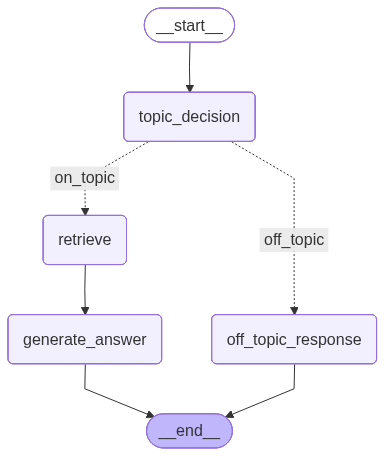

In [11]:
# Import Image and display to show graph inside notebook
from IPython.display import Image, display

# Import Mermaid drawing method for graph visualization
from langchain_core.runnables.graph import MermaidDrawMethod

# Display workflow graph as an image
display(

    # Convert graph into image format
    Image(

        # Generate graph diagram using Mermaid
        graph.get_graph().draw_mermaid_png(

            # Use Mermaid API to draw the graph
            draw_method=MermaidDrawMethod.API
        )
    )
)

In [12]:
graph.invoke(input={
    "messages": [HumanMessage(content="Who is the owner and what are the timings?")]
})

{'messages': [HumanMessage(content='Who is the owner and what are the timings?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='The context does not mention the owner of Peak Performance Gym. \n\nAs for the timings, Peak Performance Gym is open:\n- Monday through Friday: 5:00 AM to 11:00 PM\n- Weekends (Saturday and Sunday): 7:00 AM to 9:00 PM\nHowever, members with Premium access can enter the gym 24/7, including holidays. The gym remains closed on major national holidays for non-Premium members.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'documents': [Document(metadata={'source': 'hours.txt'}, page_content='Peak Performance Gym is open Monday through Friday from 5:00 AM to 11:00 PM. On weekends, our hours are 7:00 AM to 9:00 PM. We remain closed on major national holidays. Members with Premium access can enter using their key cards 24/7, including holidays.'),
  Document(metadata={'source': 'trainers.txt'}, page_content='

In [13]:
graph.invoke(input={
    "messages": [HumanMessage(content="What does the company Apple do?")]
})

{'messages': [HumanMessage(content='What does the company Apple do?', additional_kwargs={}, response_metadata={}),
  AIMessage(content="I'm sorry! I cannot answer this question!", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'on_topic': 'No'}